=== Dataset Exploration ===
Number of classes: 4
Classes: ['dent', 'normal', 'scratch', 'stain']

dent: 120 images
normal: 120 images
scratch: 120 images
stain: 120 images

Total images: 480


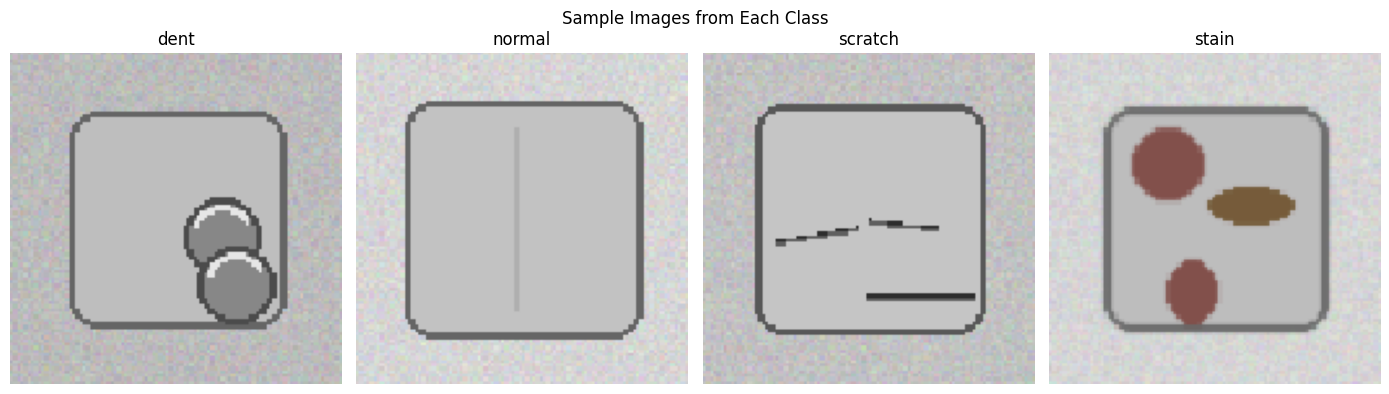


Sample image size: (96, 96)


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Define paths
data_dir = 'images'
classes = ['dent', 'normal', 'scratch', 'stain']

# Task 1 & 2: Dataset Exploration
print("=== Dataset Exploration ===")
print(f"Number of classes: {len(classes)}")
print(f"Classes: {classes}\n")

total = 0
for cls in classes:
    path = os.path.join(data_dir, cls)
    count = len(os.listdir(path))
    total += count
    print(f"{cls}: {count} images")
print(f"\nTotal images: {total}")

# Show sample images from each class
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, cls in enumerate(classes):
    path = os.path.join(data_dir, cls)
    img_file = os.listdir(path)[0]
    img = load_img(os.path.join(path, img_file), target_size=(128, 128))
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')
plt.suptitle('Sample Images from Each Class')
plt.tight_layout()
plt.savefig('results/sample_images.png')
plt.show()

# Check image dimensions
sample_img = load_img(os.path.join(data_dir, 'normal', os.listdir(os.path.join(data_dir,'normal'))[0]))
print(f"\nSample image size: {sample_img.size}")

## Task 1: Problem Identification
This is an **Image Classification** problem. The dataset contains images of manufactured products with 4 categories of surface conditions. The goal is to classify each image into one of four classes: normal, dent, scratch, or stain. Classification is appropriate because each image belongs to exactly one category.

## Task 2: Dataset Exploration
- **Classes:** dent, normal, scratch, stain
- **Images per class:** 120 each (perfectly balanced)
- **Total images:** 480
- **Image size:** 96x96 pixels
- **Class imbalance:** None — dataset is perfectly balanced

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# Task 3: Image Preprocessing
IMG_SIZE = 64
BATCH_SIZE = 32

# Load all images
X, y = [], []
for label, cls in enumerate(classes):
    path = os.path.join(data_dir, cls)
    for img_file in os.listdir(path):
        img = load_img(os.path.join(path, img_file), target_size=(IMG_SIZE, IMG_SIZE))
        X.append(img_to_array(img))
        y.append(label)

X = np.array(X) / 255.0  # Normalize
y = np.array(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Pixel range:", X_train.min(), "-", X_train.max())

X_train: (384, 64, 64, 3)
X_test: (96, 64, 64, 3)
Pixel range: 0.1764706 - 1.0


## Task 3: Image Preprocessing
- Images resized to 64x64 pixels
- Pixel values normalized to range [0, 1]
- 80/20 train-test split with stratification
- Train: 384 images, Test: 96 images

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Task 4: CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,716 (2.61 MB)

 Trainable params: 683,716 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.3062 - loss: 1.3778 - val_accuracy: 0.2208 - val_loss: 1.3915
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3225 - loss: 1.3547 - val_accuracy: 0.5455 - val_loss: 1.1877
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5407 - loss: 1.0888 - val_accuracy: 0.5844 - val_loss: 0.9438
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5896 - loss: 0.9507 - val_accuracy: 0.6234 - val_loss: 0.8512
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6515 - loss: 0.8159 - val_accuracy: 0.5714 - val_loss: 0.8087
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7394 - loss: 0.7174 - val_accuracy: 0.7013 - val_loss: 0.6733
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7818 - loss: 0.5685 - val_accuracy: 0.7922 - val_loss: 0.5013
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8502 - loss: 0.4285 - val_accuracy: 0.8571 - v

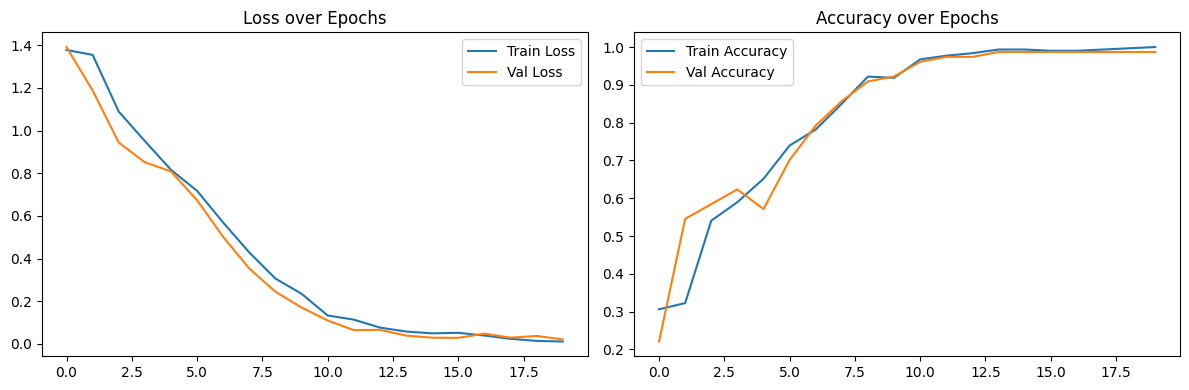


Test Accuracy: 0.9896
Test Loss: 0.0293
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


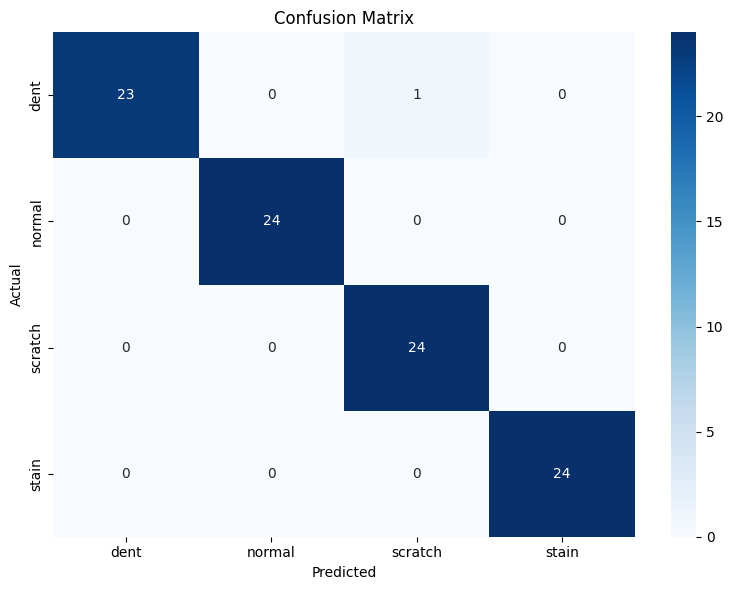


Classification Report:
              precision    recall  f1-score   support

        dent       1.00      0.96      0.98        24
      normal       1.00      1.00      1.00        24
     scratch       0.96      1.00      0.98        24
       stain       1.00      1.00      1.00        24

    accuracy                           0.99        96
   macro avg       0.99      0.99      0.99        96
weighted avg       0.99      0.99      0.99        96



In [4]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Task 5: Train the model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Plot accuracy and loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/accuracy_loss_curves.png')
plt.show()

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Confusion matrix
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=classes))


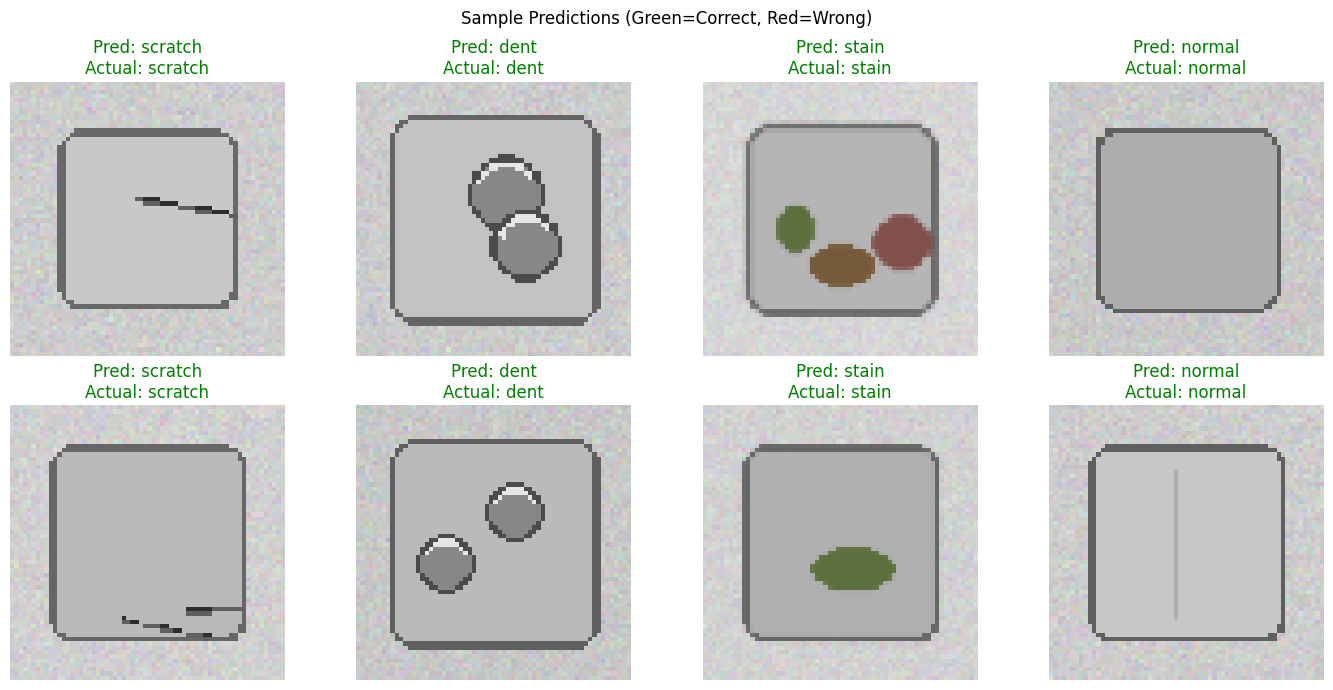

In [5]:
# Sample predictions on test images
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
indices = np.random.choice(len(X_test), 8, replace=False)

for i, idx in enumerate(indices):
    ax = axes[i//4][i%4]
    ax.imshow(X_test[idx])
    pred = classes[y_pred[idx]]
    actual = classes[y_test[idx]]
    color = 'green' if pred == actual else 'red'
    ax.set_title(f'Pred: {pred}\nActual: {actual}', color=color)
    ax.axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout()
plt.savefig('sample_predictions/prediction_outputs.png')
plt.show()

## Task 5: Model Training and Evaluation

- **Test Accuracy: 98.96%** — excellent performance
- **Test Loss: 0.0293**
- The confusion matrix shows near-perfect classification across all 4 classes
- Only 1 misclassification (dent predicted as scratch)
- F1-score: 0.99 across all classes

## Task 6 & 7: CNN Concepts and Business Use Case
See README.md for detailed explanations (As per instruction).